# Notebook 4 - Machine Learning

## Objectives

- Prepare earthquake features
- Standardize data
- Determine optimal clusters
- Train K-Means model
- Visualize seismic clusters
- Save clustered dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
earthquakes = pd.read_csv(
    "data/processed/earthquakes_processed.csv"
)

earthquakes.head()

,Time,Date,Year,Month,Day,Hour,Weekday,Latitude,Longitude,Depth_km,Magnitude,Location
0,2025-12-30 23:51:36.674000+00:00,2025-12-30,2025,12,30,23,Tuesday,39.4639,142.7562,35.000,4.8,"69 km E of Yamada, Japan"
1,2025-12-30 22:36:09.826000+00:00,2025-12-30,2025,12,30,22,Tuesday,3.0448,128.8654,10.000,4.5,"173 km NNE of Tobelo, Indonesia"
2,2025-12-30 22:25:43.819000+00:00,2025-12-30,2025,12,30,22,Tuesday,60.5503,-140.1190,5.000,3.3,"113 km N of Yakutat, Alaska"
3,2025-12-30 22:19:46.317000+00:00,2025-12-30,2025,12,30,22,Tuesday,39.5984,143.3045,27.735,4.8,"117 km E of Miyako, Japan"
4,2025-12-30 22:14:01.822000+00:00,2025-12-30,2025,12,30,22,Tuesday,62.7050,-149.2790,59.600,2.5,"51 km ENE of Chase, Alaska"


In [3]:
features = earthquakes[
    [
        "Latitude",
        "Longitude",
        "Depth_km",
        "Magnitude"
    ]
]

In [4]:
features = features.dropna()

print(features.shape)

(20000, 4)


In [5]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

In [6]:
inertia = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_features)

    inertia.append(model.inertia_)

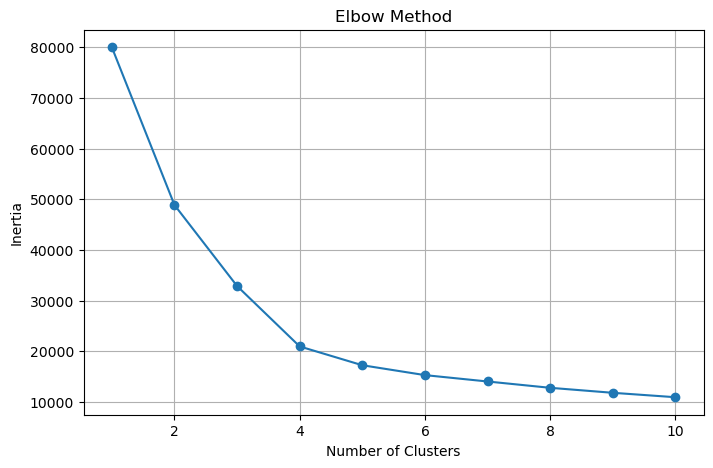

In [7]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.grid(True)

plt.show()

In [8]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(scaled_features)

In [9]:
clustered_data = features.copy()

clustered_data["Cluster"] = clusters

clustered_data.head()

,Latitude,Longitude,Depth_km,Magnitude,Cluster
0,39.4639,142.7562,35.000,4.8,2
1,3.0448,128.8654,10.000,4.5,3
2,60.5503,-140.1190,5.000,3.3,1
3,39.5984,143.3045,27.735,4.8,2
4,62.7050,-149.2790,59.600,2.5,1


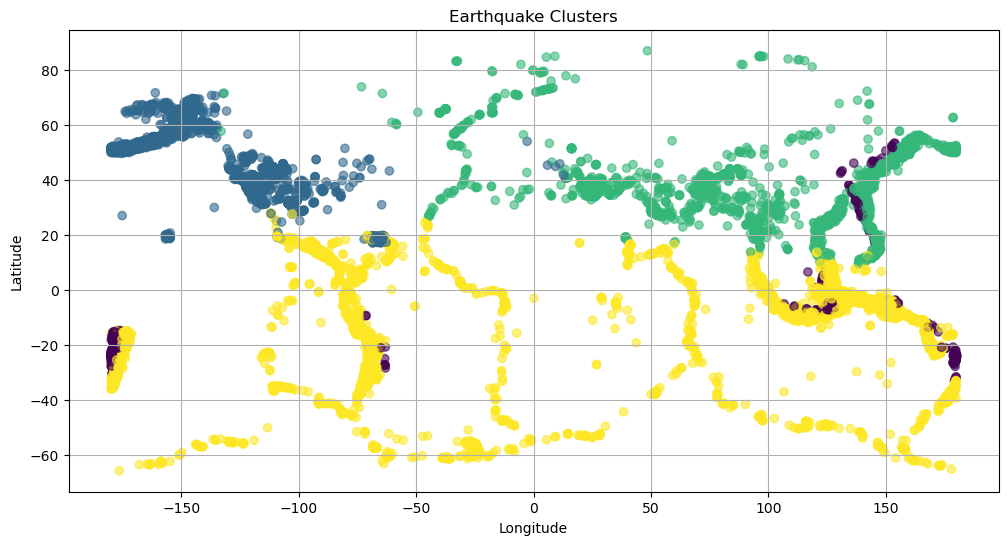

In [10]:
plt.figure(figsize=(12,6))

plt.scatter(
    clustered_data["Longitude"],
    clustered_data["Latitude"],
    c=clustered_data["Cluster"],
    alpha=0.6
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Earthquake Clusters")

plt.grid(True)

plt.show()

In [11]:
cluster_summary = (
    clustered_data
    .groupby("Cluster")
    .agg(
        Count=("Cluster","count"),
        Average_Magnitude=("Magnitude","mean"),
        Average_Depth=("Depth_km","mean")
    )
)

cluster_summary

,Count,Average_Magnitude,Average_Depth
Cluster,,,
0,726,4.367218,508.684383
1,7265,2.986795,26.312343
2,6735,4.470277,34.250692
3,5274,4.552465,57.013177


In [12]:
clustered_data.to_csv(
    "data/processed/earthquake_clusters.csv",
    index=False
)

cluster_summary.to_csv(
    "outputs/reports/cluster_summary.csv"
)

print("Cluster analysis saved successfully.")

Cluster analysis saved successfully.
